<a href="https://colab.research.google.com/github/Abhshek-78/Abhshek-78/blob/main/CNNproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical


In [34]:
df=pd.read_csv("fashion-mnist_train.csv")


In [35]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
df .shape

(5204, 785)

In [37]:
df_test=pd.read_csv("fashion-mnist_test.csv")

In [38]:
df_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103.0,87.0,56.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0,0,0,0,0,0,0,0,0,...,34.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,0,0,0,0,0,0,14,53,99,...,0.0,0.0,0.0,0.0,63.0,53.0,31.0,0.0,0.0,0.0
3,2,0,0,0,0,0,0,0,0,0,...,137.0,126.0,140.0,0.0,133.0,224.0,222.0,56.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6135,2,0,0,0,0,0,0,0,1,0,...,1.0,0.0,0.0,146.0,157.0,23.0,0.0,0.0,0.0,0.0
6136,7,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6137,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6138,8,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
df = df.fillna(0)


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Columns: 785 entries, label to pixel784
dtypes: float64(700), int64(85)
memory usage: 31.2 MB


In [41]:
df.isnull().sum()

,0
label,0
pixel1,0
pixel2,0
pixel3,0
pixel4,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


In [42]:
X_train = df.drop(columns=['label']).values
y_train = df['label'].values

X_test = df_test.drop(columns=['label']).values
y_test = df_test['label'].values

In [43]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [44]:
Xtrain_images=X_train.reshape(-1,28,28)
X_test_images=X_test.reshape(-1,28,28)

In [45]:
Xtrain_images

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [46]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

In [47]:
y_train_cat

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [48]:
perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')

])

In [49]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy",metrics=["accuracy"] )

In [50]:
hist_per=perceptron.fit(Xtrain_images,y_train_cat,epochs=5 , batch_size=32,validation_data=(X_test_images,y_test_cat),verbose=1)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5231 - loss: 1.5816
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6820 - loss: 1.0388
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7191 - loss: 0.8926
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7396 - loss: 0.8157
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7565 - loss: 0.7660


In [51]:
acc_per=perceptron.evaluate(X_test_images,y_test_cat,verbose=0)[1]

In [52]:
acc_per

0.7460911870002747

In [53]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')

])


In [54]:
ann_compiler=ann.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"] )

In [55]:
ann_compiler

In [56]:
ann_hist=ann.fit(Xtrain_images,y_train_cat,epochs=5 , batch_size=32,validation_data=(X_test_images,y_test_cat),verbose=1)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7267 - loss: 0.8158
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8138 - loss: 0.5324
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8328 - loss: 0.4663
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8474 - loss: 0.4345
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8593 - loss: 0.3882


In [57]:
acc_ann=ann.evaluate(X_test_images,y_test_cat,verbose=0)[1]

In [58]:
acc_ann

0.8278501629829407

In [59]:
Xtrain_cnn=Xtrain_images.reshape(-1,28,28,1)
X_test_cnn=X_test_images.reshape(-1,28,28,1)

In [60]:
cnn = Sequential([
    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu"
    ),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(10, activation="softmax")
])

In [64]:
cnn.compile(optimizer="adam", loss="categorical_crossentropy",metrics=["accuracy"] )

In [65]:
cnn_hist=cnn.fit(Xtrain_cnn,y_train_cat,epochs=5 , batch_size=32,validation_freq=(X_test_cnn,y_test_cat),verbose=1)


Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8691 - loss: 0.3607
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8860 - loss: 0.3202
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8899 - loss: 0.3078
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9003 - loss: 0.2763
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9041 - loss: 0.2605


In [66]:
acc_cnn=cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]
acc_cnn

0.8690553903579712

In [86]:
def plotting(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label="train")
    plt.plot(history.history['val_accuracy'], label="val")
    plt.title(f'{title} - Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label="train")
    plt.plot(history.history['val_loss'], label="val")
    plt.title(f'{title} - Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

KeyError: 'val_accuracy'

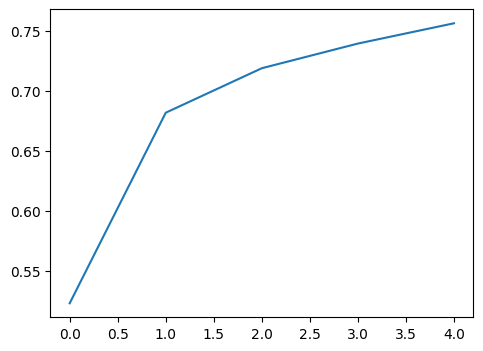

In [87]:
plotting(hist_per, "Perceptron")

KeyError: 'val_accuracy'

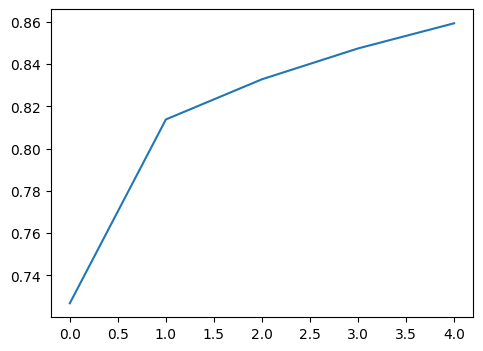

In [88]:
plotting(ann_hist, "ANN")

KeyError: 'val_accuracy'

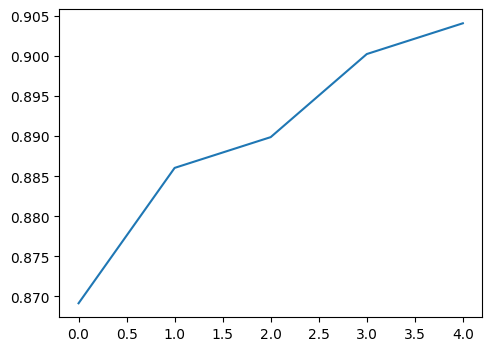

In [89]:
plotting(cnn_hist, "CNN")

### Validation Accuracy of Models

In [90]:
print(f"Perceptron Validation Accuracy: {acc_per:.4f}")
print(f"ANN Validation Accuracy: {acc_ann:.4f}")
print(f"CNN Validation Accuracy: {acc_cnn:.4f}")

Perceptron Validation Accuracy: 0.7461
ANN Validation Accuracy: 0.8279
CNN Validation Accuracy: 0.8691


### Comparison of Validation Accuracy

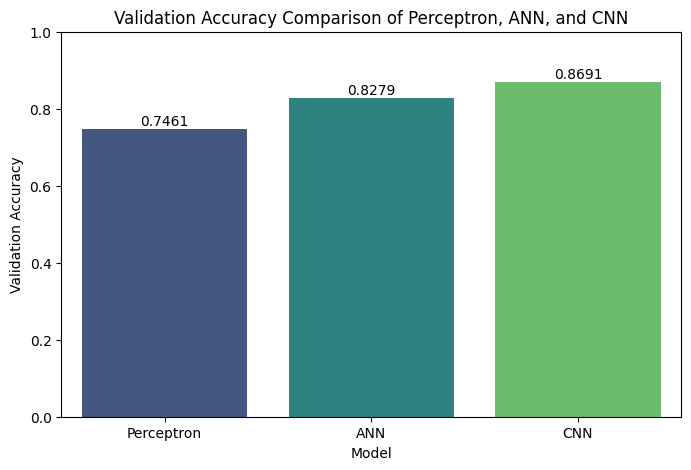

In [91]:
models = ['Perceptron', 'ANN', 'CNN']
accuracies = [acc_per, acc_ann, acc_cnn]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Validation Accuracy Comparison of Perceptron, ANN, and CNN')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.ylim(0, 1)
for index, value in enumerate(accuracies):
    plt.text(index, value + 0.01, f'{value:.4f}', ha='center')
plt.show()

### Side-by-Side Prediction Comparison

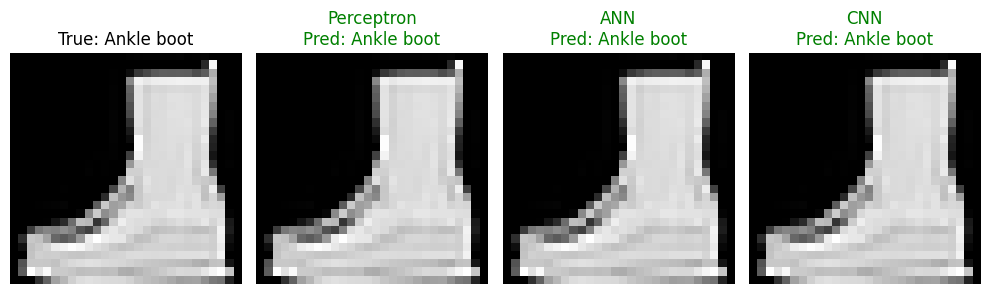

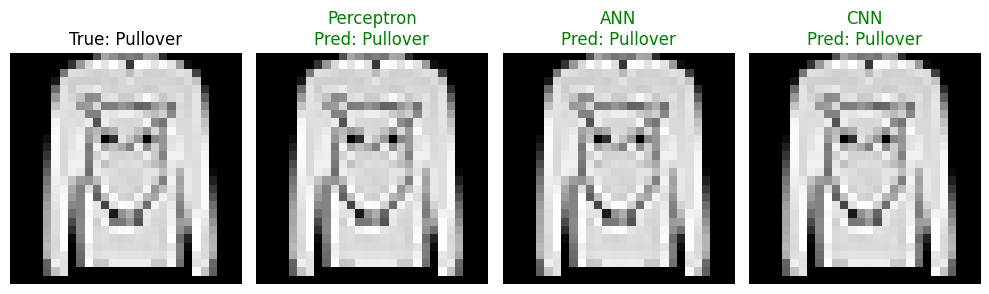

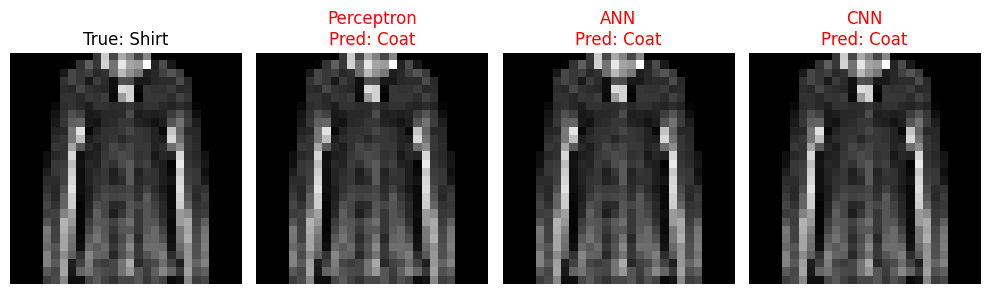

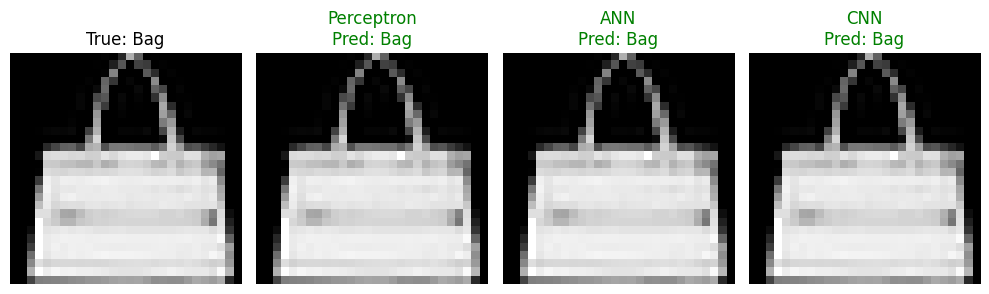

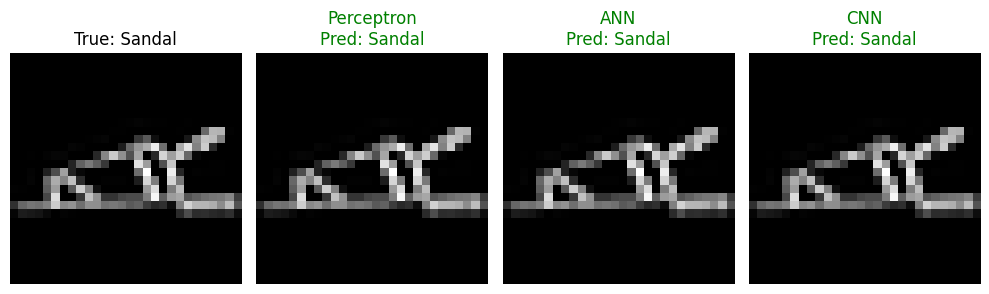

In [96]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def plot_predictions(image_index):

    original_image = X_test_images[image_index]
    true_label = y_test[image_index]
    cnn_image = np.expand_dims(original_image, axis=-1)
    cnn_image = np.expand_dims(cnn_image, axis=0) # Add batch dimension

    per_ann_image = np.expand_dims(original_image, axis=0)
    per_pred_prob = perceptron.predict(per_ann_image, verbose=0)[0]
    ann_pred_prob = ann.predict(per_ann_image, verbose=0)[0]
    cnn_pred_prob = cnn.predict(cnn_image, verbose=0)[0]
    per_pred = np.argmax(per_pred_prob)
    ann_pred = np.argmax(ann_pred_prob)
    cnn_pred = np.argmax(cnn_pred_prob)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(original_image, cmap='gray')
    plt.title(f"True: {class_names[true_label]}")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(original_image, cmap='gray') # Show image again for context
    color_per = 'green' if per_pred == true_label else 'red'
    plt.title(f"Perceptron\nPred: {class_names[per_pred]}", color=color_per)
    plt.axis('off')


    plt.subplot(1, 4, 3)
    plt.imshow(original_image, cmap='gray')
    color_ann = 'green' if ann_pred == true_label else 'red'
    plt.title(f"ANN\nPred: {class_names[ann_pred]}", color=color_ann)
    plt.axis('off')


    plt.subplot(1, 4, 4)
    plt.imshow(original_image, cmap='gray')
    color_cnn = 'green' if cnn_pred == true_label else 'red'
    plt.title(f"CNN\nPred: {class_names[cnn_pred]}", color=color_cnn)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


np.random.seed(42)
sample_indices = np.random.randint(0, len(X_test_images), 5)

for idx in sample_indices:
    plot_predictions(idx)